In [109]:
import os
os.environ["SCIPY_ARRAY_API"] = "1"

import pandas as pd
import numpy as np

# Scikit-learn y métricas
from sklearn.model_selection       import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline              import Pipeline
from sklearn.preprocessing         import FunctionTransformer, StandardScaler
from sklearn.metrics               import classification_report, confusion_matrix, roc_curve, auc, f1_score

# Clasificadores
from sklearn.linear_model          import LogisticRegression
from sklearn.svm                   import SVC
from sklearn.ensemble              import RandomForestClassifier, VotingClassifier
from sklearn.neighbors             import KNeighborsClassifier
from sklearn.naive_bayes           import MultinomialNB
from sklearn.neural_network        import MLPClassifier
from sklearn.ensemble              import StackingClassifier

# Boosting libraries
import xgboost as xgb
import lightgbm as lgb

import matplotlib.pyplot as plt

# Cargar datos
ruta = "../datos_raw/SMSSpamCollection"
df = pd.read_csv(ruta, sep="\t", header=None, names=["label", "text"], encoding="utf-8")
df["label_bin"] = df["label"].map({"ham": 0, "spam": 1})
print(df.shape)
print(df.label.value_counts())
df.sample(5, random_state=42)

# Distribución de longitudes
df["longitud"] = df.text.str.len()
df.groupby("label").longitud.describe()


(5572, 3)
label
ham     4825
spam     747
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,71.482487,58.440652,2.0,33.0,52.0,93.0,910.0
spam,747.0,138.670683,28.873603,13.0,133.0,149.0,157.0,223.0


In [58]:
# 3.1. Limpieza básica
df.drop_duplicates(subset="text", inplace=True)
df["text"] = df.text.str.lower()

# 3.2. Extraemos features numéricas
from sklearn.preprocessing import FunctionTransformer

X = df["text"]
y = df["label"].map({"ham":0,"spam":1})

feats_num = extra_features(X)
display(feats_num.head())

,longitud_texto,num_palabras,num_puntuacion,prop_numerico
0,111,20,9,0.00000
1,29,6,6,0.00000
2,155,28,6,0.16129
3,49,11,6,0.00000
4,61,13,2,0.00000


In [104]:
import re

def enhanced_features(text_series: pd.Series) -> pd.DataFrame:
    base = extra_features(text_series)
    base["has_link"] = text_series.str.contains(r"http|www", regex=True).astype(int)
    base["num_exclamaciones"] = text_series.apply(lambda s: s.count("!"))
    base["mayusculas_ratio"] = text_series.apply(lambda s: sum(c.isupper() for c in s) / max(len(s), 1))
    base["sospechoso"] = text_series.str.contains(r"free|win|click|offer|urgent", case=False).astype(int)
    return base

# Ejemplo rápido
df_feats = enhanced_features(pd.Series(["Hola, ¿cómo estás? 123", "Esta es otra línea."]))
print(df_feats)

   length  num_digits  num_uppercase  num_exclamations  has_link  \
0      22           3              1                 0         0   
1      19           0              1                 0         0   

   num_exclamaciones  mayusculas_ratio  sospechoso  
0                  0          0.045455           0  
1                  0          0.052632           0  


In [99]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.metrics import classification_report
import pandas as pd

# Asegúrate de que 'df' contiene la columna "text" y 'y' contiene las etiquetas (spam o ham)
# Ejemplo:
# df = pd.read_csv("SMSSpamCollection", sep="\t", names=["label", "text"])
# y = df["label"].map({"ham": 0, "spam": 1})

# Función que extrae características adicionales (debes definirla previamente)
def extra_features(series):
    return pd.DataFrame({
        "length": series.str.len(),
        "num_digits": series.str.count(r"\d"),
        "num_uppercase": series.str.count(r"[A-Z]"),
        "num_exclamations": series.str.count(r"!"),
    })

# División del dataset
X_train, X_val, y_train, y_val = train_test_split(
    df[["text"]], y, test_size=0.2, random_state=42, stratify=y
)

# Vectorizador de texto (TF-IDF con n-gramas)
text_vect = TfidfVectorizer(ngram_range=(1, 2), max_df=0.9, min_df=5)

# Pipeline para características numéricas adicionales
numeric_pipe = Pipeline([
    ("feat", FunctionTransformer(lambda X: extra_features(X.squeeze()), validate=False)),
    ("scale", StandardScaler())
])

# Preprocesamiento combinado: texto + características numéricas
preproc = ColumnTransformer([
    ("tfidf", text_vect, "text"),
    ("num", numeric_pipe, "text")
])

# Pipeline general con regresión logística
pipe = Pipeline([
    ("pre", preproc),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

# Búsqueda de hiperparámetros
param_grid = {
    "clf__C": [0.01, 0.1, 1, 10]
}

gs = GridSearchCV(pipe, param_grid, cv=5, scoring="f1", n_jobs=-1)
gs.fit(X_train, y_train)

# Resultados
print("MejorParams:", gs.best_params_)
y_pred = gs.predict(X_val)
print(classification_report(y_val, y_pred, target_names=["ham", "spam"]))


MejorParams: {'clf__C': 10}
              precision    recall  f1-score   support

         ham       0.99      1.00      1.00       903
        spam       0.99      0.94      0.96       131

    accuracy                           0.99      1034
   macro avg       0.99      0.97      0.98      1034
weighted avg       0.99      0.99      0.99      1034



In [103]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Feature engineering
def extra_features(series):
    return pd.DataFrame({
        "length": series.str.len(),
        "num_digits": series.str.count(r"\d"),
        "num_uppercase": series.str.count(r"[A-Z]"),
        "num_exclamations": series.str.count(r"!"),
    })

# División correcta
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    df["text"], y, test_size=0.2, random_state=42, stratify=y
)

# Construcción del pipeline
def build_pipeline(vectorizer):
    text_transformer = Pipeline([
        ("vect", vectorizer)
    ])

    numeric_transformer = Pipeline([
        ("feat", FunctionTransformer(lambda X: extra_features(X.squeeze()), validate=False)),
        ("scale", StandardScaler())
    ])

    preprocessor = ColumnTransformer([
        ("text", text_transformer, "text"),
        ("num", numeric_transformer, "text")
    ])

    pipe = Pipeline([
        ("pre", preprocessor),
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ])

    return pipe

# Ejemplo de vectorizador
vectorizadores = {
    "tfidf_1_3": TfidfVectorizer(ngram_range=(1,3), min_df=5, max_df=0.9)
}

# Entrenamiento
pipe_ejemplo = build_pipeline(vectorizadores["tfidf_1_3"])
pipe_ejemplo.fit(X_train_raw.to_frame(name="text"), y_train)
print("Entrenado pipeline de ejemplo, score en train:", pipe_ejemplo.score(X_train_raw.to_frame(name="text"), y_train))

Entrenado pipeline de ejemplo, score en train: 0.9794437726723095


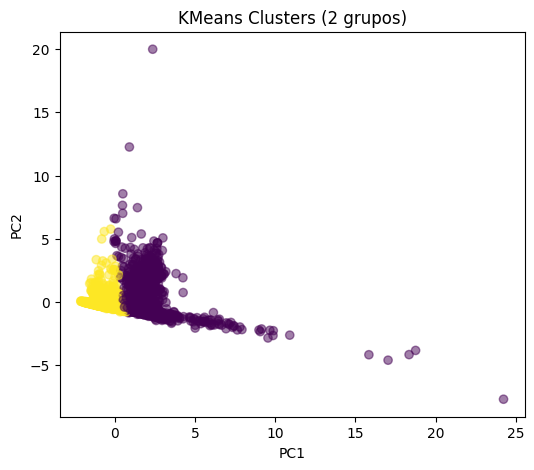

In [65]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Extraer matriz de features
X_feats = preproc.fit_transform(df[["text"]])

# KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_feats)

# PCA a 2D
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X_feats)

# Plot
plt.figure(figsize=(6,5))
plt.scatter(X2[:,0], X2[:,1], c=clusters, alpha=0.5)
plt.title("KMeans Clusters (2 grupos)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.savefig('kmeans_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

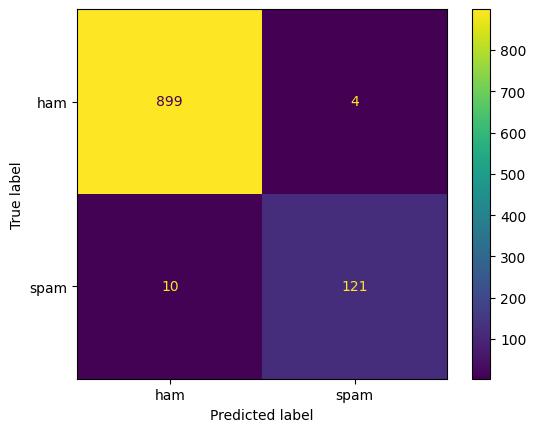

In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["ham","spam"])
disp.plot()
plt.savefig('confusion_matrixDisplay.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
datos_raw = r"C:\Me\School\ADT\proyecto_sms_spam\tecnica_ia\datos_raw"
csv_file  = "new_messages.csv"
file_path = os.path.join(datos_raw, csv_file)

new_df = pd.read_csv(
    file_path,
    encoding='latin-1',    #
    sep=None,              # autodetecta el separador
    engine='python',       # tolera mejor errores
    on_bad_lines='skip'    # ignora líneas mal formadas
)

# 5) Predecimos y asignamos etiquetas
preds = gs.best_estimator_.predict(new_df[["text"]])
new_df["predicted_label"] = ["spam" if p=="spam" or p==1 else "ham" for p in preds]

# 6) Guardamos resultados
out_file = "predictions.csv"
new_df.to_csv(out_file, index=False)
print(f"Predicciones guardadas en {out_file}")

In [92]:
import joblib
joblib.dump(gs.best_estimator_, "spam_classifier.pkl")
print("Modelo guardado en spam_classifier.pkl")

PicklingError: Can't pickle <function build_pipeline.<locals>.<lambda> at 0x0000011F40BA1580>: it's not found as __main__.build_pipeline.<locals>.<lambda>